Usar unrotate = True destruye la información sobre la posición del crop en la instancia de AnnotatedPage. Además, reduce la calidad de las imágenes por usar interpolación bicúbica, y esta misma interpolación introduce artefactos visuales en los bordes de la imagen. Úsese solamente en caso de revisión manual de las imágenes, y NO para el código de generación del dataset.
-- -- Llevas un 39.67%
-- -- TAREA 332 -- ANOTACIÓN 1 --
-- -- --       Completada por: pambignacio8             
-- -- -- Último actualización: pambignacio8              con fecha de 2026-02-23 15:12:40.484209
	 (332) Caja <ImageBox poligonal KotWxsgS87 de la tarea (332).¡Rotación cancelada!>:


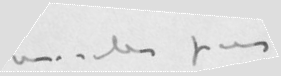

<IPython.core.display.Latex object>



	 (332) Caja <ImageBox poligonal ydPjZ4UtEq de la tarea (332).¡Rotación cancelada!>:


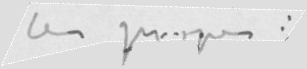

<IPython.core.display.Latex object>



	 (332) Caja <ImageBox poligonal 9mI-CXY7JI de la tarea (332).¡Rotación cancelada!>:


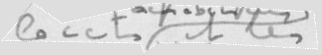

<IPython.core.display.Latex object>



	 (332) Caja <ImageBox poligonal sES-y04ZNp de la tarea (332).¡Rotación cancelada!>:


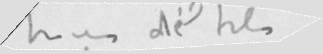

<IPython.core.display.Latex object>



	 (332) Caja <ImageBox poligonal LehE7XMpFp de la tarea (332).¡Rotación cancelada!>:


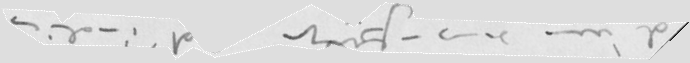

<IPython.core.display.Latex object>



	 (332) Caja <ImageBox poligonal HGvNRU0DCD de la tarea (332).¡Rotación cancelada!>:


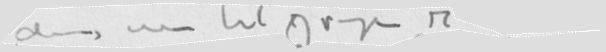

<IPython.core.display.Latex object>



	 (332) Caja <ImageBox poligonal 8orwKeStWy de la tarea (332).¡Rotación cancelada!>:


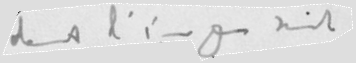

<IPython.core.display.Latex object>



	 (332) Caja <ImageBox poligonal 1drw-LKT-G de la tarea (332).¡Rotación cancelada!>:


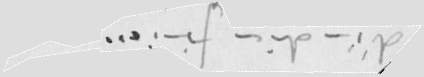

<IPython.core.display.Latex object>



	 (332) Caja <ImageBox poligonal EjbYa0Bqrz de la tarea (332).¡Rotación cancelada!>:


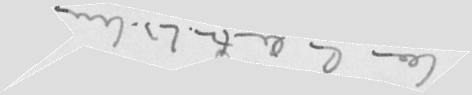

<IPython.core.display.Latex object>



	 (332) Caja <ImageBox poligonal dNal3edaPF de la tarea (332).¡Rotación cancelada!>:


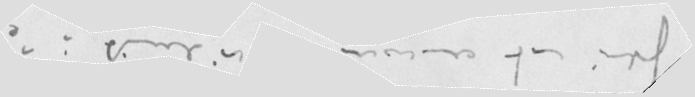

<IPython.core.display.Latex object>

KeyboardInterrupt: Se ha parado el proceso

In [1]:
from IPython.display import Latex
from downloaders.LabelStudioInterface import LabelStudioInterface
from IPython.display import clear_output
from preprocessing.classes.helper_to_classes import get_image_path_from_task
from preprocessing.classes.AnnotatedPage import AnnotatedPage
from PIL import Image

LS = LabelStudioInterface()
LS_export_data = LS.raw_tasks()

# download_updated_export(export_filepath)

# convert_label_studio_json(export_filepath, simplified_filepath)
# LS = load_export(simplified_filepath)
#cajas revisadas hasta la 341.
max_revised = 125 #poner aquí la página por la que se está revisando.

tasks = [task for task in sorted(LS_export_data, key = lambda task : task["id"]) if task["id"] > max_revised]
for task in tasks:
    task_id = task["id"]
    if int(task_id) != 332:
        continue

    img = Image.open(get_image_path_from_task(task))


    for (k,ann) in enumerate(task["annotations"]):
        Ann = AnnotatedPage(ann, task_id, img, unrotate = True, cc_ordering = True)
        print(f"-- -- Llevas un {len([x for x in LS.raw_tasks() if x["id"] <= task_id]) / len(LS_export_data) * 100:.2f}%")
        print(f"-- -- TAREA {task_id} -- ANOTACIÓN {k} --")
        print(f"-- -- --       Completada por: {Ann.completer:<25}")
        print(f"-- -- -- Último actualización: {Ann.updater:<25} con fecha de {Ann.last_update_time}")
        boxes_by_height = sorted(list(Ann.image_boxes.values()), key = lambda box: (box.polygon.centroid.y, box.polygon.centroid.x))


        for (i, box) in enumerate(boxes_by_height):
            print(f"\t ({task_id}) Caja {repr(box)}:")
            #no generamos el recorte tal cual, sino que lo metemos
            #en un rectángulo (esto hace más fácil leer)
            display(Ann.generate_collage([box.id]))
            display(Latex(box.associated_fragments[0].text))
            print("\n")

        a = input("Continuamos? (vacío para continuar)")
        if a.lower() != "":
            raise KeyboardInterrupt("Se ha parado el proceso")

        clear_output(wait = True)